In [1]:
import matplotlib
import matplotlib.font_manager as fm
import os
import sys
import shutil

def update_matplotlib_font_cache():
    """更新 matplotlib 字体缓存"""

    print("=== 更新 matplotlib 字体缓存 ===")
    print(f"Python: {sys.version}")
    print(f"Matplotlib: {matplotlib.__version__}")

    # 1. 获取缓存目录
    cache_dir = matplotlib.get_cachedir()
    print(f"\n1. 缓存目录: {cache_dir}")

    # 2. 查找并删除字体缓存文件
    font_cache_files = []
    if os.path.exists(cache_dir):
        for file in os.listdir(cache_dir):
            if file.startswith('fontlist-') and file.endswith('.json'):
                font_cache_files.append(os.path.join(cache_dir, file))

    if font_cache_files:
        print(f"\n2. 找到 {len(font_cache_files)} 个字体缓存文件:")
        for file in font_cache_files:
            print(f"   - {os.path.basename(file)}")
            os.remove(file)
            print(f"     已删除")
    else:
        print("\n2. 未找到字体缓存文件")

    # 3. 尝试不同的重建方法
    print("\n3. 尝试重建字体缓存...")

    methods = [
        ("fm.fontManager._rebuild", lambda: fm.fontManager._rebuild() if hasattr(fm.fontManager, '_rebuild') else None),
        ("fm._rebuild", lambda: fm._rebuild() if hasattr(fm, '_rebuild') else None),
        ("重新扫描字体", lambda: fm.fontManager.findSystemFonts(fm.fontManager.defaultFontPaths, fontext='ttf')),
    ]

    success = False
    for method_name, method_func in methods:
        try:
            result = method_func()
            if result is not None:
                print(f"   ✓ {method_name}: 成功")
                success = True
                break
            else:
                print(f"   - {method_name}: 方法不存在")
        except Exception as e:
            print(f"   ✗ {method_name}: 失败 - {e}")

    # 4. 重新加载模块
    print("\n4. 重新加载字体管理器...")
    import importlib
    importlib.reload(fm)

    # 5. 验证结果
    print("\n5. 验证字体列表...")
    font_count = len(fm.fontManager.ttflist)
    print(f"   当前字体数量: {font_count}")

    # 查找 Arial 相关字体
    arial_fonts = []
    for font in fm.fontManager.ttflist:
        name_lower = font.name.lower()
        if 'arial' in name_lower or 'liberation' in name_lower:
            arial_fonts.append(font.name)

    if arial_fonts:
        print(f"\n   找到 Arial/Liberation 字体:")
        for font in sorted(set(arial_fonts)):
            print(f"     - {font}")
    else:
        print(f"\n   未找到 Arial/Liberation 字体")

    return success

# 运行更新
if __name__ == "__main__":
    success = update_matplotlib_font_cache()
    if success:
        print("\n✅ 字体缓存更新完成！请重启 Python/Jupyter 内核")
    else:
        print("\n⚠️  字体缓存更新可能未完全成功，建议尝试手动方法")

=== 更新 matplotlib 字体缓存 ===
Python: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:16:04) [GCC 11.2.0]
Matplotlib: 3.10.7

1. 缓存目录: /home/lzs/.cache/matplotlib

2. 找到 1 个字体缓存文件:
   - fontlist-v390.json
     已删除

3. 尝试重建字体缓存...
   - fm.fontManager._rebuild: 方法不存在
   - fm._rebuild: 方法不存在
   ✗ 重新扫描字体: 失败 - 'FontManager' object has no attribute 'findSystemFonts'

4. 重新加载字体管理器...

5. 验证字体列表...
   当前字体数量: 469

   找到 Arial/Liberation 字体:
     - Arial
     - Arial Black
     - Liberation Mono
     - Liberation Sans
     - Liberation Sans Narrow
     - Liberation Serif

⚠️  字体缓存更新可能未完全成功，建议尝试手动方法


In [2]:
import numpy as np
import matplotlib.font_manager as fm

# 获取字体管理器实例
font_manager = fm.FontManager()

# 重建字体缓存
font_manager.findfont('Arial')  # 这会触发字体搜索
# 读取保存的数组，路径要和保存时完全一致
load_path = 'energy_2_6.npy'
energy_6 = np.load(load_path)
energy_6 = energy_6+2.2245745

print("数组维度：", energy_6.shape)

数组维度： (584,)


In [3]:
# 读取保存的数组，路径要和保存时完全一致
load_path = 'energy_2_5.npy'
energy_5 = np.load(load_path)

energy_5 = energy_5 + 3.599041146422197
print("数组维度：", energy_5.shape)

数组维度： (673,)


In [4]:
# 读取保存的数组，路径要和保存时完全一致
load_path = 'energy_2_4.npy'
energy_4 = np.load(load_path)

energy_4 = energy_4 + 5.51892996921924
print("数组维度：", energy_4.shape)

数组维度： (362,)


In [5]:
# 读取保存的数组，路径要和保存时完全一致
load_path = 'energy_2_3.npy'
energy_3 = np.load(load_path)

energy_3 = energy_3 + 11.650256388464074
print("数组维度：", energy_3.shape)

数组维度： (217,)


In [6]:
# 读取保存的数组，路径要和保存时完全一致
load_path = 'energy_2_2.npy'
energy_2 = np.load(load_path)

energy_2 =energy_2+24.444145412140404

print("数组维度：", energy_2.shape)

数组维度： (209,)


/tmp/ipykernel_1754201/913652898.py:70: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, np.max(np.concatenate(data_list)) + 0.5)  # y轴上下留边


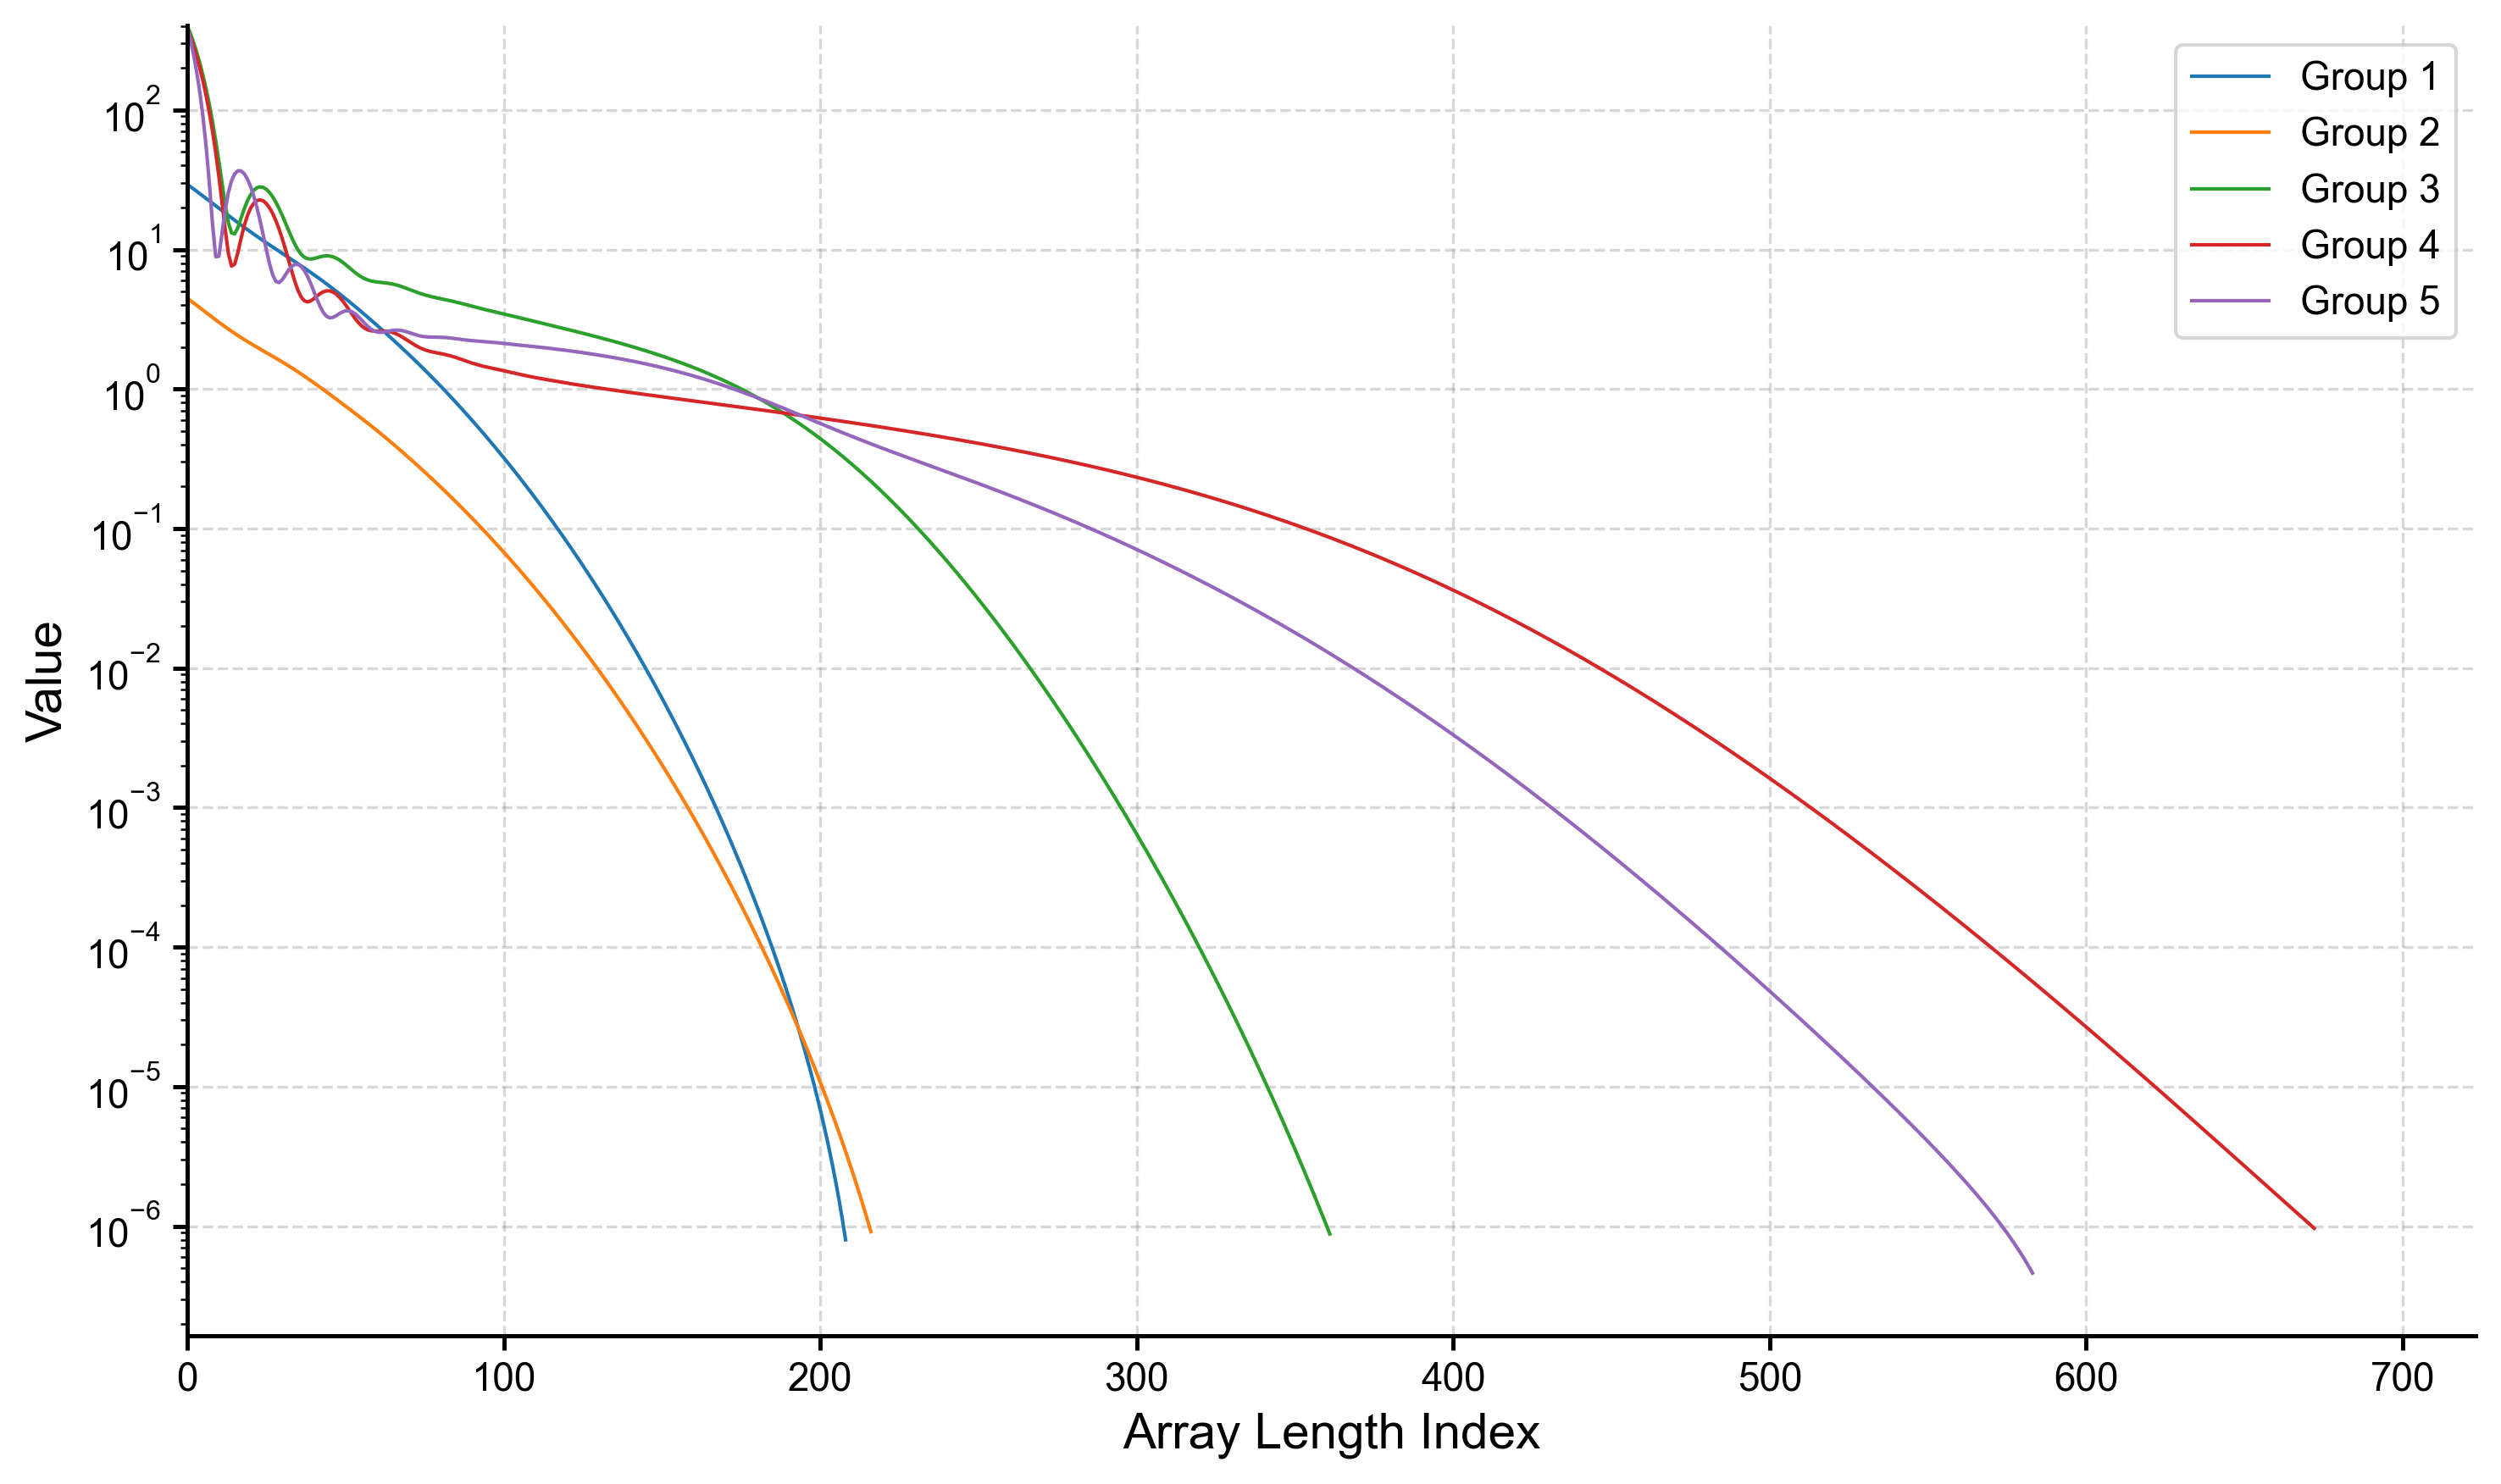

In [7]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 从您之前的输出中，我们知道 Arial 字体路径
arial_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'

# 创建 FontProperties 对象
arial_font = fm.FontProperties(fname=arial_path)
# -------------------------- 1. 设置全局绘图参数（科研级配置） --------------------------
# 设置默认字体（Arial是科研期刊常用字体，无衬线更清晰）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12  # 基础字体大小
plt.rcParams['axes.linewidth'] = 1.2  # 坐标轴线条宽度
plt.rcParams['figure.dpi'] = 300  # 画布默认清晰度
plt.rcParams['savefig.dpi'] = 300  # 保存图片的清晰度
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# -------------------------- 2. 定义5组示例数组（替换为你的真实数据） --------------------------
# 示例：5组长度不同的数组，你可以替换成自己的实际数据
arr1 = np.array(energy_2)
arr2 = np.array(energy_3)
arr3 = np.array(energy_4)
arr4 = np.array(energy_5)
arr5 = np.array(energy_6)

# 整理成列表，方便遍历
data_list = [arr1, arr2, arr3, arr4, arr5]
# 定义每组的label（替换为你的实际分组名称）
labels = ['Group 1', 'Group 2', 'Group 3', 'Group 4', 'Group 5']

# -------------------------- 3. 科研常用配色（Nature/Science期刊风格） --------------------------
# 颜色选择原则：对比度高、无荧光色、适合黑白打印识别，避免红绿色盲不友好的组合
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # 蓝、橙、绿、红、紫（科研经典配色）

# -------------------------- 4. 绘图核心逻辑 --------------------------
fig, ax = plt.subplots(figsize=(10, 6))  # 设置画布大小（宽10英寸，高6英寸）

# 遍历每组数据绘制曲线
for i, arr in enumerate(data_list):
    # 根据数组长度生成对应的x轴数据
    x = np.arange(len(arr))
    # 绘制曲线：设置颜色、线条宽度、标记点（增强辨识度）、label
    ax.plot(x, arr, color=colors[i], linewidth=1, label=labels[i])

ax.set_yscale('log')  # 核心修改：Y轴改为对数坐标

# -------------------------- 5. 细节优化（科研绘图必备） --------------------------
# 设置x轴、y轴标签（带字体大小）
ax.set_xlabel('Array Length Index', fontsize=14, )
ax.set_ylabel('Value', fontsize=14, )

# 设置标题（按需修改）
#ax.set_title('Comparison of 5 Groups of Arrays', fontsize=16, pad=20)

# 添加图例（位置最优，避免遮挡数据）
ax.legend(loc='best', fontsize=11, frameon=True, fancybox=True, shadow=False)

# 添加网格（浅灰色虚线，辅助阅读，不喧宾夺主）
ax.grid(True, linestyle='--', alpha=0.3, color='gray', linewidth=0.8)

# 优化坐标轴：只保留左、下边框（科研绘图简洁风格）
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 调整刻度范围（可选，根据数据自动适配）
ax.set_xlim(0, max(len(arr) for arr in data_list) +50)  # x轴左右留边
ax.set_ylim(0, np.max(np.concatenate(data_list)) + 0.5)  # y轴上下留边

# 调整刻度标签大小
ax.tick_params(axis='both', labelsize=11, length=4, width=1.2)

# -------------------------- 6. 保存图片（高分辨率，支持矢量图） --------------------------
# 保存为PNG（位图，适合预览）或PDF（矢量图，适合期刊发表）
plt.tight_layout()  # 自动调整布局，避免标签被裁剪
#fig.savefig('scientific_array_plot.png', dpi=300, bbox_inches='tight')  # PNG格式
# fig.savefig('scientific_array_plot.pdf', bbox_inches='tight')  # PDF矢量格式（推荐科研投稿用）

# 显示图像
plt.show()